#  <span style='color:blue'>  Credit Card Default Prediction_CAPSTONE PROJECT-1
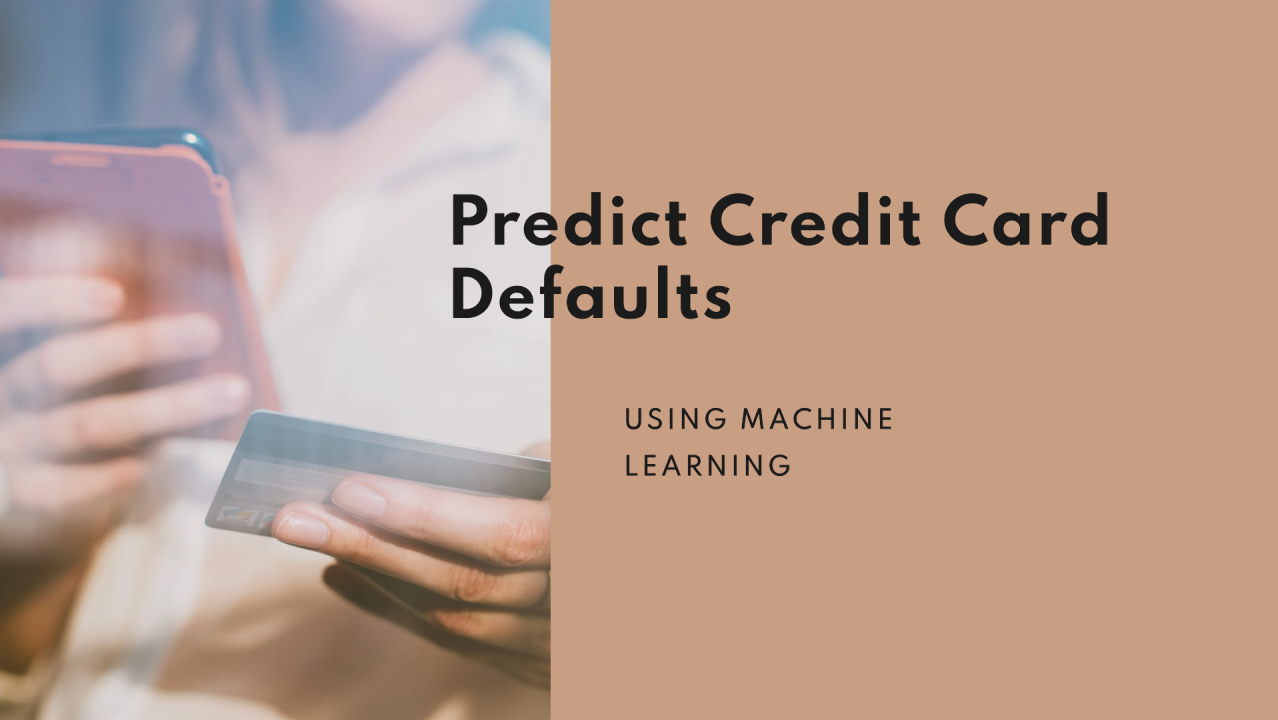

##  <span style='color:blue'>  Good and Bad Customers for Granting Credit
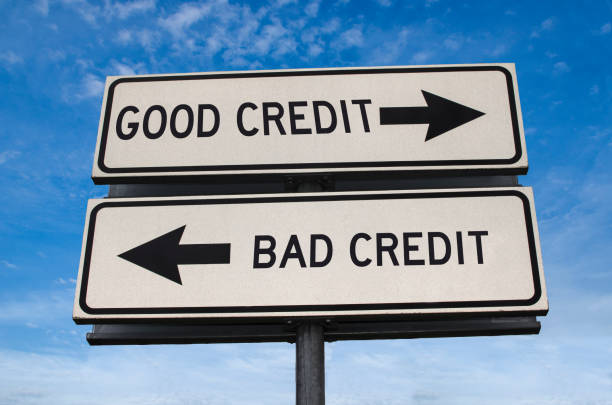

#  <span style='color:blue'>  **Student Name:** Madhusudan Manna_Batch-13
---
**Objective:** Build a classification model using classification algorithms and compare their performances to predict the credibility of the customer, in order to minimize the risk and maximize the profit of a bank.

## Task 1: Import Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn modules
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


## Task 2: Load and Read the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('Credit_Card_Default.csv')
print("Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")
df.head(10)

Dataset loaded successfully!
Shape of dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


## Task 3: Dataset Information

In [3]:
# Display basic dataset information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2             

In [4]:
# Statistical summary
print("\nStatistical Description:")
df.describe()


Statistical Description:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
# Check column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


## Task 4: Check for Missing Values and Duplicates

In [6]:
# Check missing values
print("Missing Values in each column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values in each column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Total missing values: 0


In [7]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Drop duplicates if any
df.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after dropping duplicates: (30000, 25)


## Task 5: Data Preprocessing

In [8]:
# Rename target column for convenience
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

# Drop the ID column (not useful for prediction)
df.drop('ID', axis=1, inplace=True)

print("Columns after preprocessing:")
print(df.columns.tolist())
print(f"\nNew shape: {df.shape}")

Columns after preprocessing:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

New shape: (30000, 24)


In [9]:
# Handle invalid/unknown categories
# EDUCATION: Replace 0, 5, 6 with 4 (others/unknown)
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# MARRIAGE: Replace 0 with 3 (others)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

print("EDUCATION value counts after cleaning:")
print(df['EDUCATION'].value_counts())
print("\nMARRIAGE value counts after cleaning:")
print(df['MARRIAGE'].value_counts())

EDUCATION value counts after cleaning:
EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

MARRIAGE value counts after cleaning:
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


## Task 6: Exploratory Data Analysis (EDA)

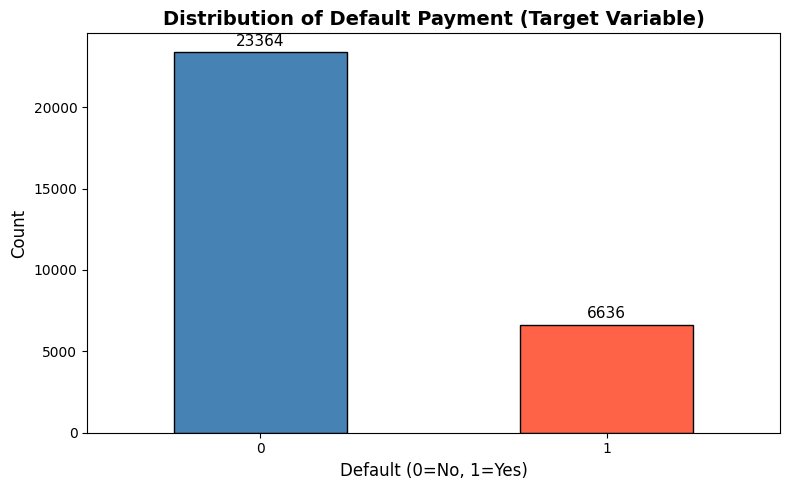


Class Distribution:
default
0    23364
1     6636
Name: count, dtype: int64
Default Rate: 22.12%


In [10]:
# Target variable distribution
plt.figure(figsize=(8, 5))
ax = df['default'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Distribution of Default Payment (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Default (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, xytext=(0, 8), textcoords='offset points')
plt.tight_layout()
plt.show()
print(f"\nClass Distribution:\n{df['default'].value_counts()}")
print(f"Default Rate: {df['default'].mean()*100:.2f}%")

<Figure size 1000x500 with 0 Axes>

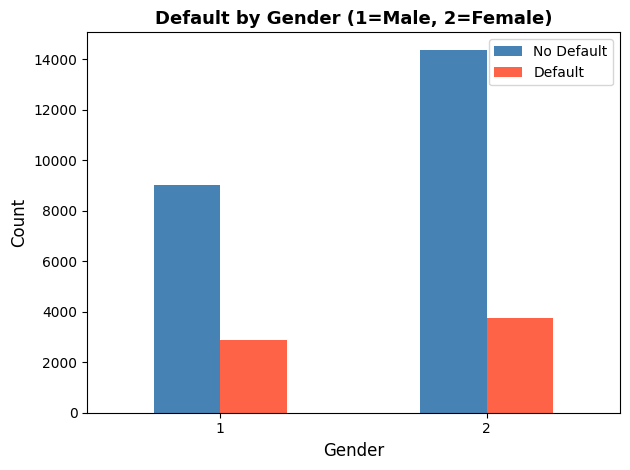

In [11]:
# Gender vs Default
plt.figure(figsize=(10, 5))
pd.crosstab(df['SEX'], df['default']).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Default by Gender (1=Male, 2=Female)', fontsize=13, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

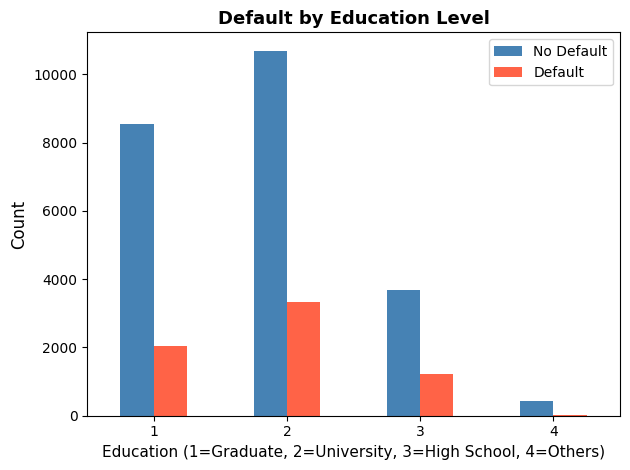

In [12]:
# Education vs Default
plt.figure(figsize=(10, 5))
pd.crosstab(df['EDUCATION'], df['default']).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Default by Education Level', fontsize=13, fontweight='bold')
plt.xlabel('Education (1=Graduate, 2=University, 3=High School, 4=Others)', fontsize=11)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

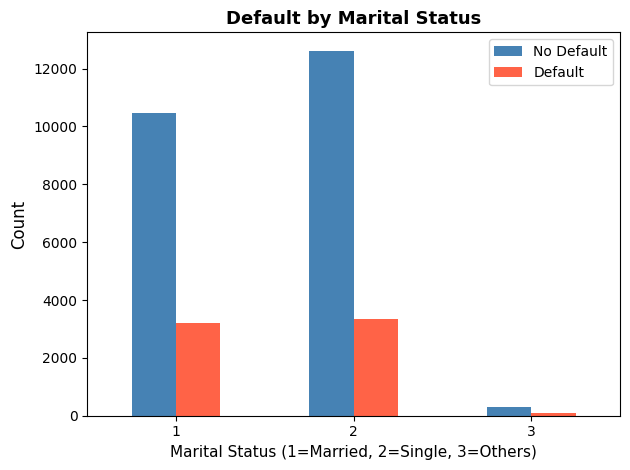

In [13]:
# Marriage vs Default
plt.figure(figsize=(10, 5))
pd.crosstab(df['MARRIAGE'], df['default']).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Default by Marital Status', fontsize=13, fontweight='bold')
plt.xlabel('Marital Status (1=Married, 2=Single, 3=Others)', fontsize=11)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.show()

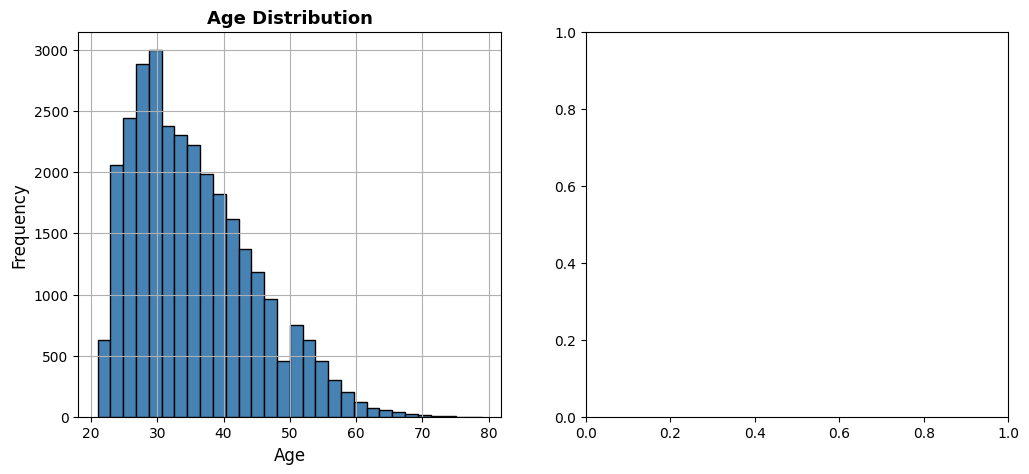

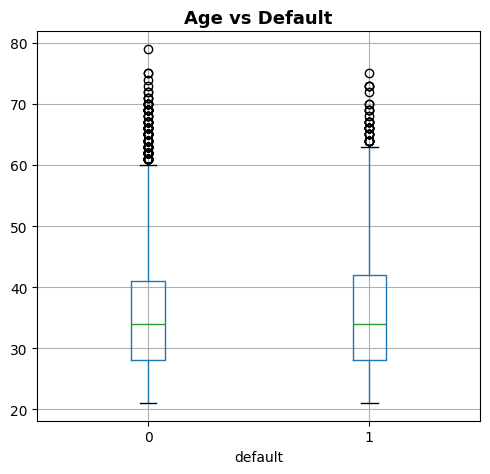

In [14]:
# Age distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['AGE'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
df.boxplot(column='AGE', by='default', figsize=(5, 5))
plt.title('Age vs Default', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.show()

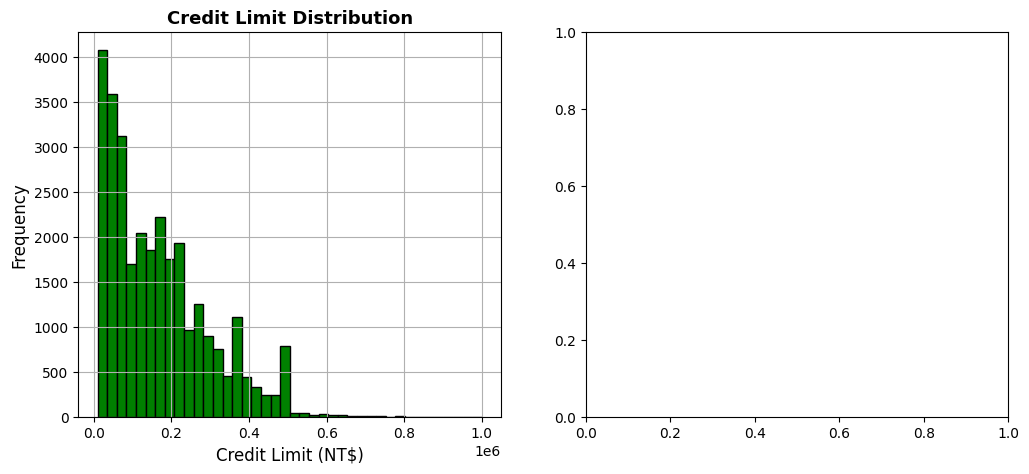

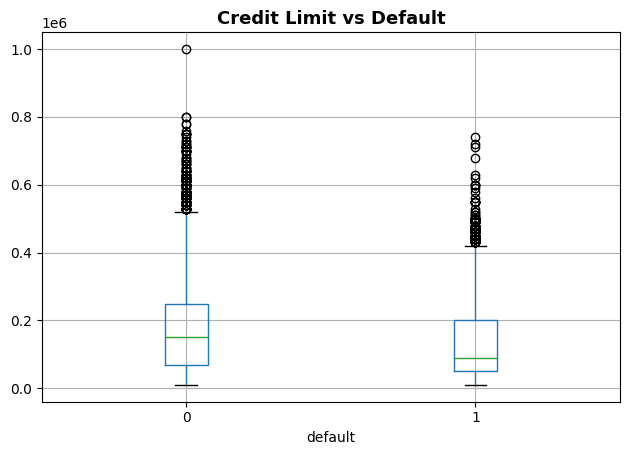

In [15]:
# Credit Limit Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['LIMIT_BAL'].hist(bins=40, color='green', edgecolor='black')
plt.title('Credit Limit Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Credit Limit (NT$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
df.boxplot(column='LIMIT_BAL', by='default')
plt.title('Credit Limit vs Default', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.show()

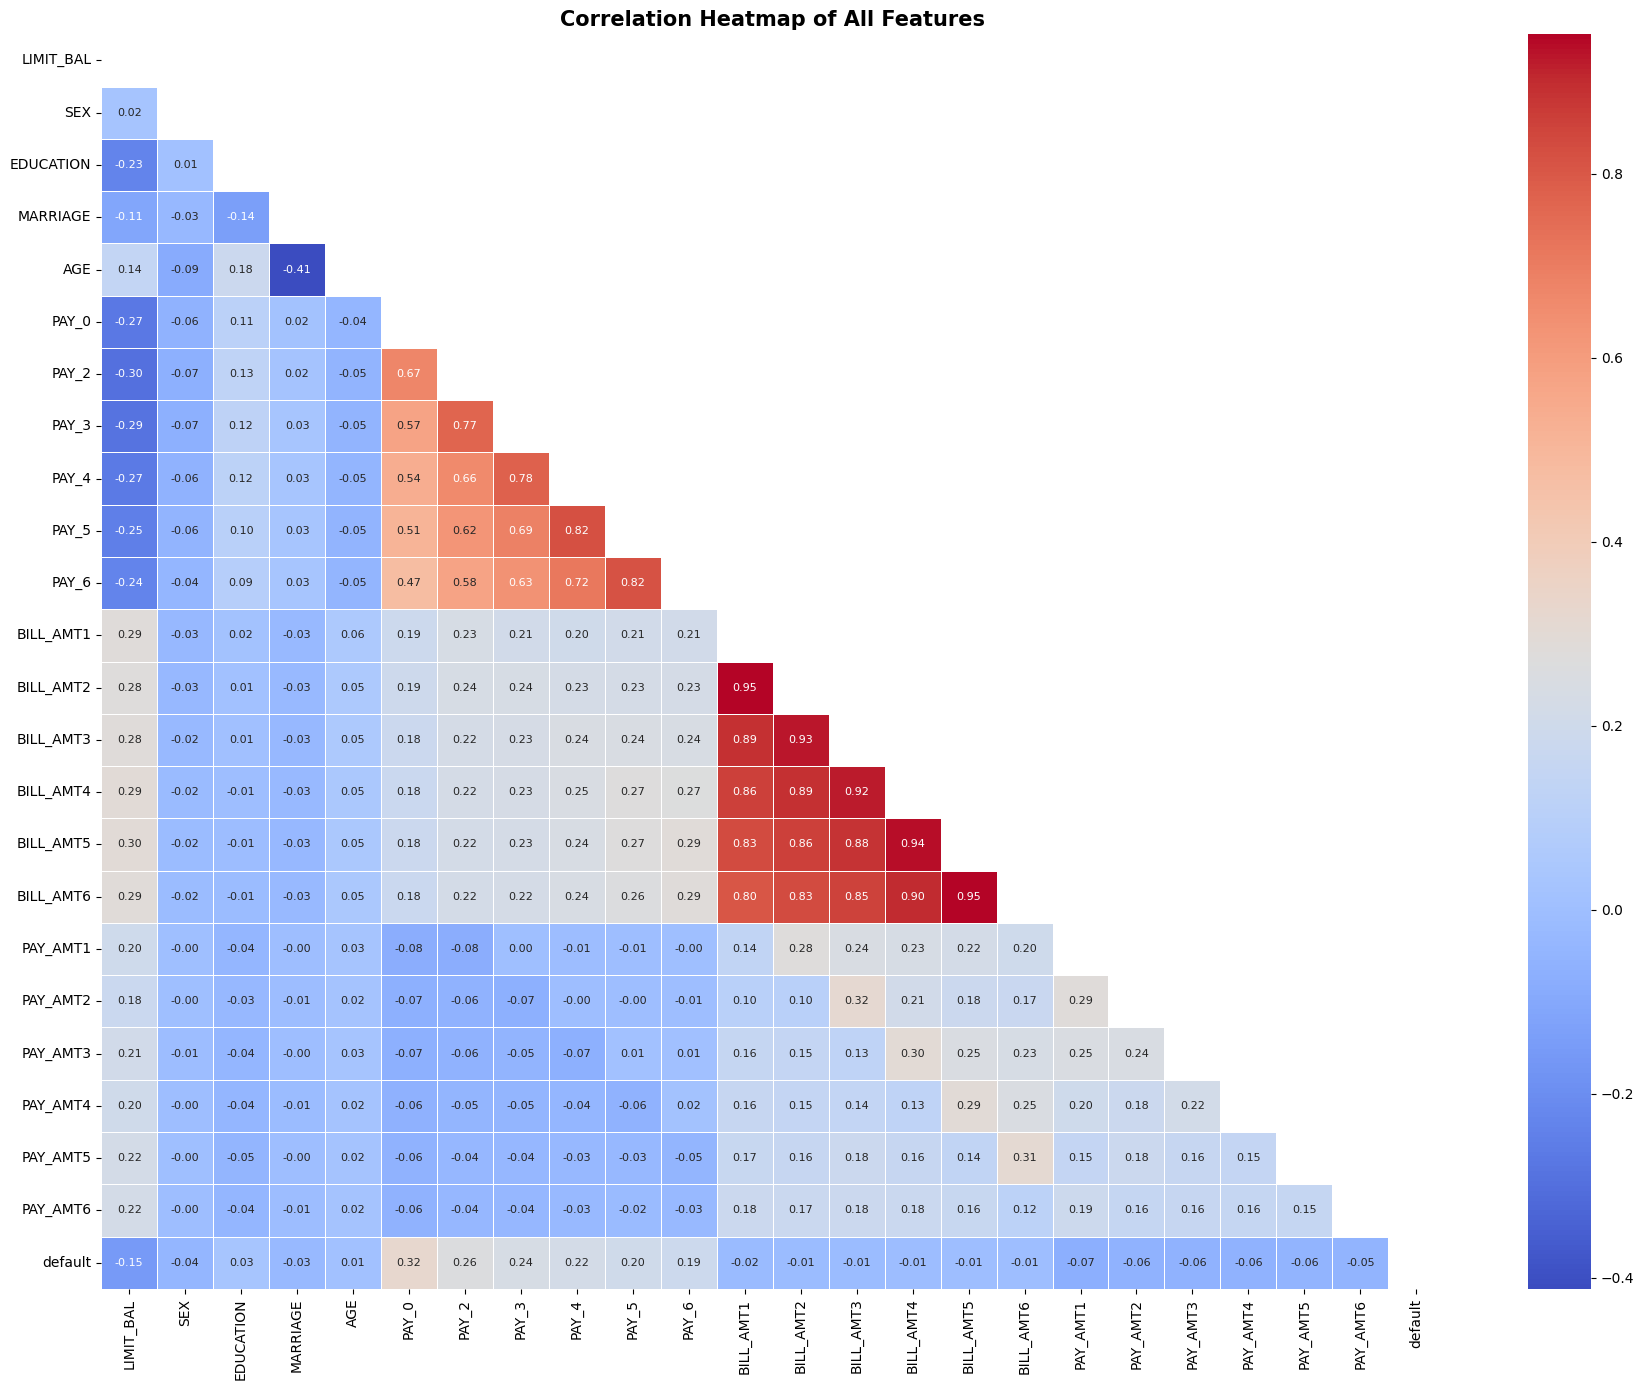

In [16]:
# Correlation Heatmap
plt.figure(figsize=(18, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of All Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

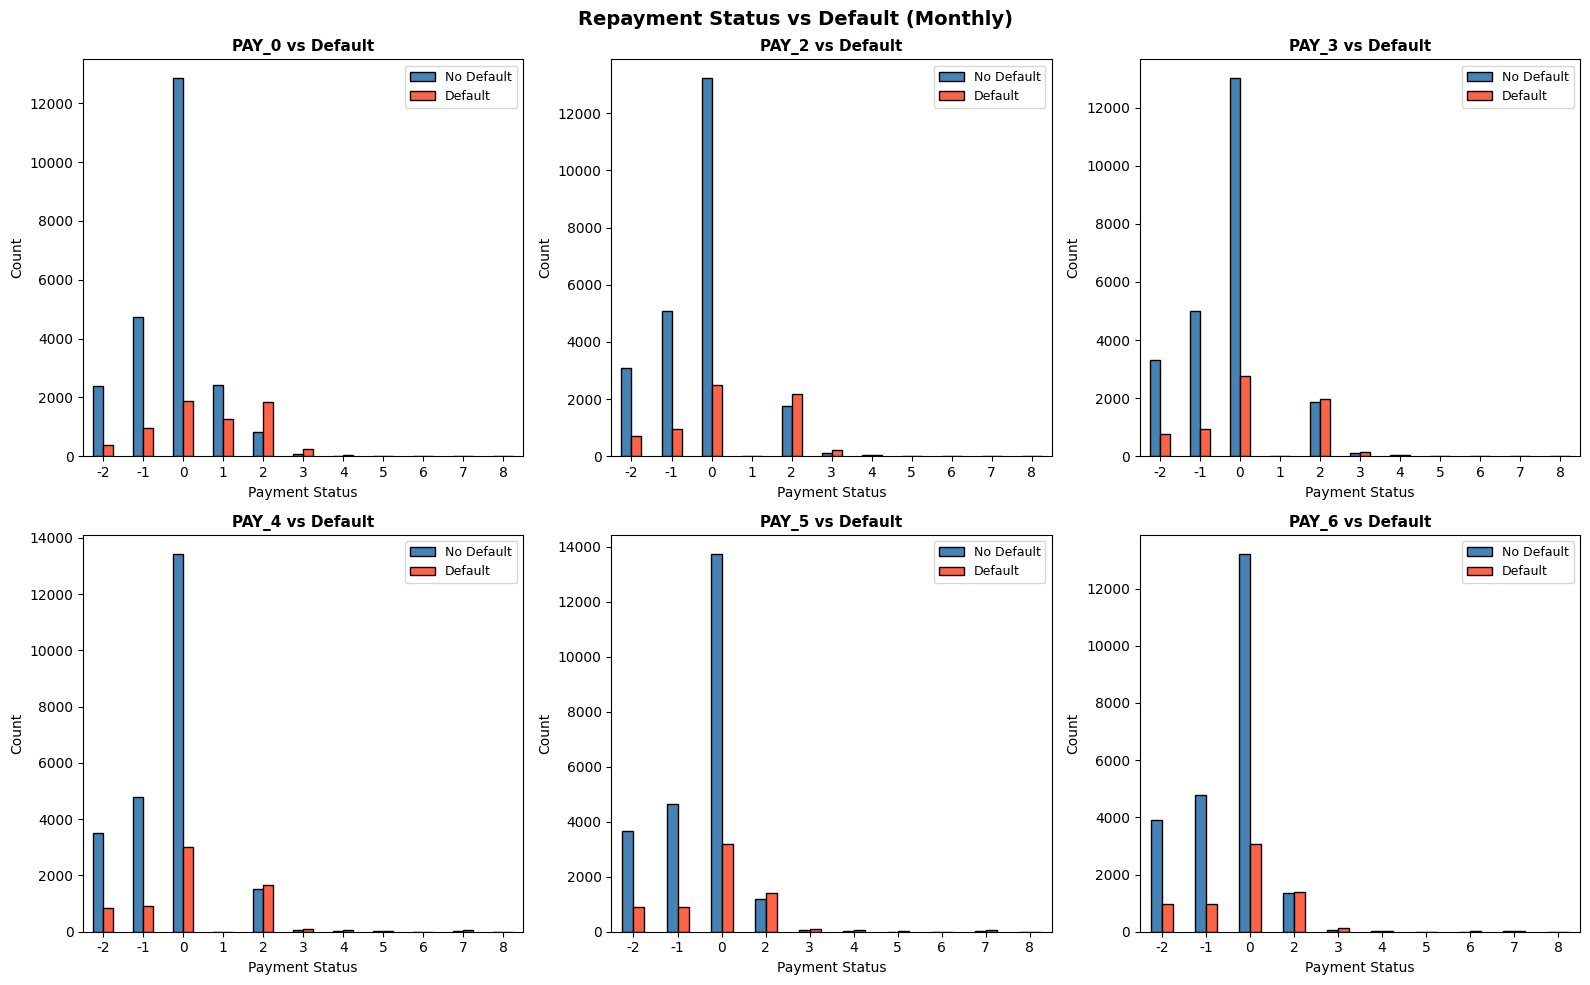

In [17]:
# Payment history analysis
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(pay_cols):
    pd.crosstab(df[col], df['default']).plot(kind='bar', ax=axes[i],
                                              color=['steelblue', 'tomato'], edgecolor='black')
    axes[i].set_title(f'{col} vs Default', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Payment Status', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(['No Default', 'Default'], fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)
plt.suptitle('Repayment Status vs Default (Monthly)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 7: Feature Engineering and Outlier Detection

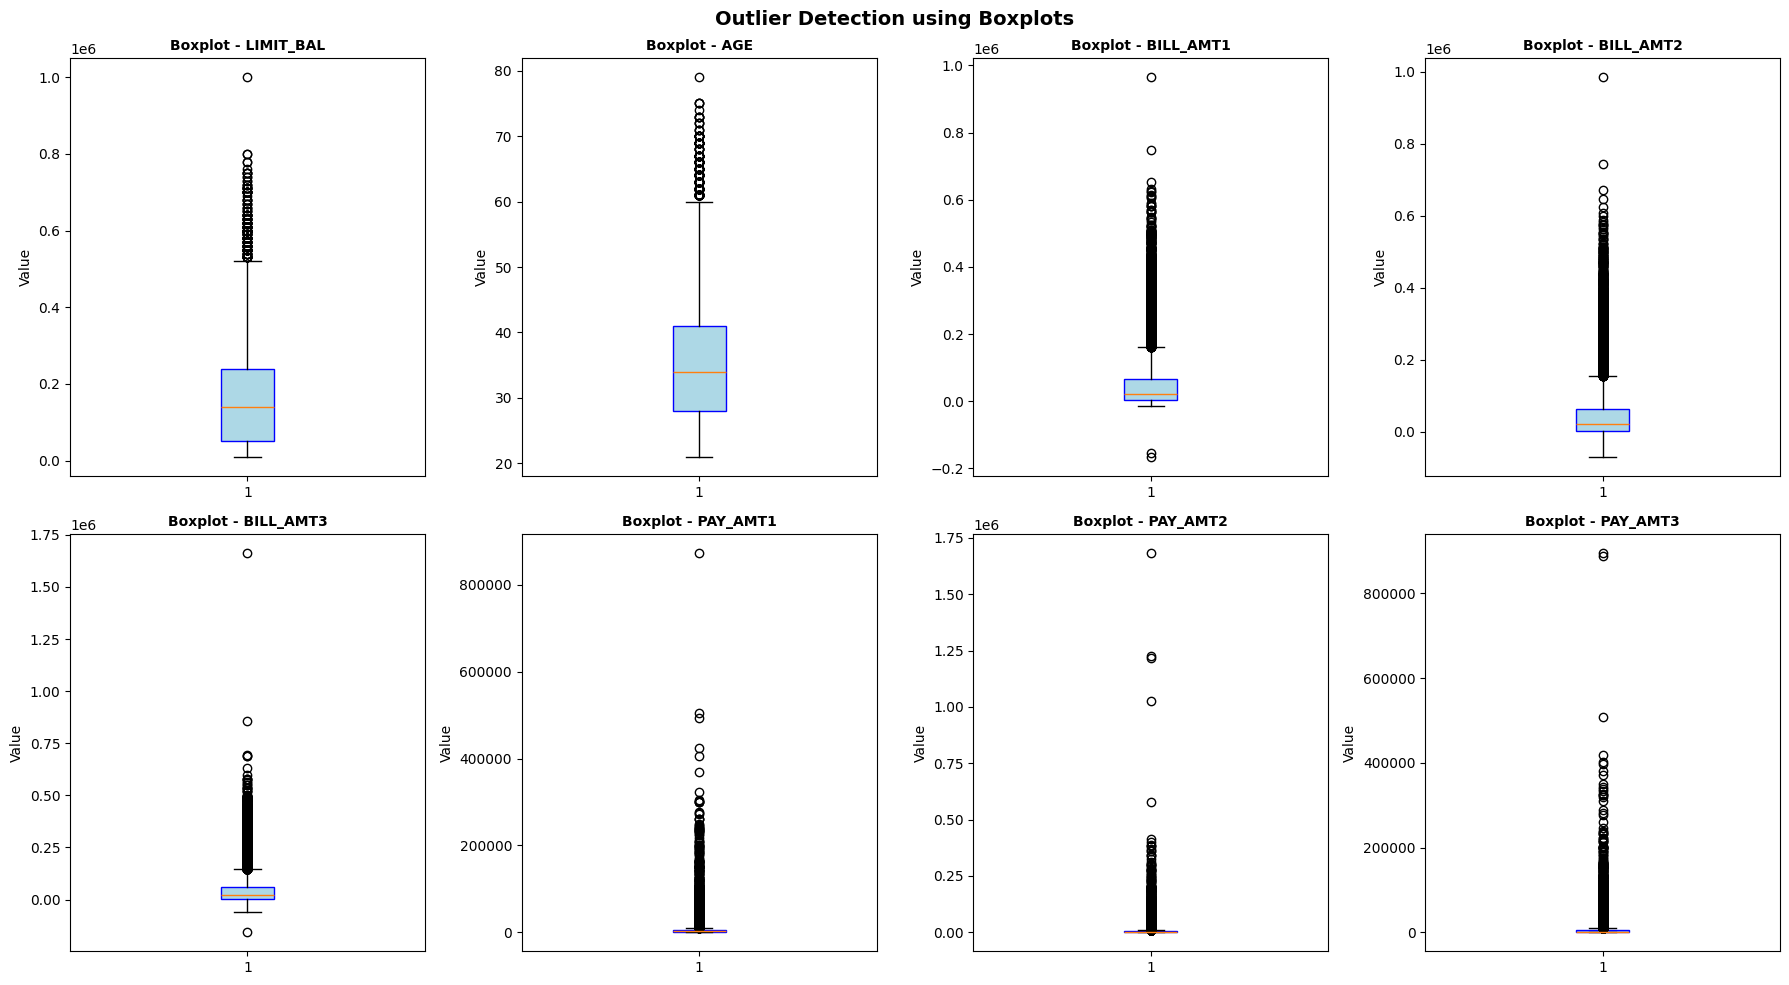

In [18]:
# Boxplot to detect outliers in numerical columns
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue'))
    axes[i].set_title(f'Boxplot - {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')
plt.suptitle('Outlier Detection using Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Feature Engineering: Create new features
# Average bill amount
df['AVG_BILL_AMT'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                          'BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)

# Average payment amount
df['AVG_PAY_AMT'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                         'PAY_AMT4','PAY_AMT5','PAY_AMT6']].mean(axis=1)

# Payment ratio - safe calculation to avoid NaN
df['PAY_RATIO'] = np.where(df['AVG_BILL_AMT'] == -1, 0.0, df['AVG_PAY_AMT'] / (df['AVG_BILL_AMT'] + 1))
df['PAY_RATIO'] = df['PAY_RATIO'].fillna(0.0)

# Average payment delay
df['AVG_PAY_DELAY'] = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)

print("New features created: AVG_BILL_AMT, AVG_PAY_AMT, PAY_RATIO, AVG_PAY_DELAY")
print(f"Updated shape: {df.shape}")
df[['AVG_BILL_AMT', 'AVG_PAY_AMT', 'PAY_RATIO', 'AVG_PAY_DELAY']].describe()

New features created: AVG_BILL_AMT, AVG_PAY_AMT, PAY_RATIO, AVG_PAY_DELAY
Updated shape: (30000, 28)


,AVG_BILL_AMT,AVG_PAY_AMT,PAY_RATIO,AVG_PAY_DELAY
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,44976.945200,5275.232094,3.765709,-0.182439
std,63260.721860,10137.946323,209.643984,0.982176
min,-56043.166667,0.000000,-1502.000000,-2.000000
25%,4781.333333,1113.291667,0.041073,-0.833333
50%,21051.833333,2397.166667,0.086189,0.000000
75%,57104.416667,5583.916667,0.597965,0.000000
max,877313.833333,627344.333333,27000.000000,6.000000


## Task 8: Prepare Features and Target Variable

In [20]:
# Define features and target
X = df.drop('default', axis=1)
y = df['default']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (30000, 27)
Target shape: (30000,)

Feature columns (27):
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'PAY_RATIO', 'AVG_PAY_DELAY']


In [21]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nClass distribution in Training set:\n{y_train.value_counts()}")
print(f"\nClass distribution in Testing set:\n{y_test.value_counts()}")

Training set size: (24000, 27)
Testing set size: (6000, 27)

Class distribution in Training set:
default
0    18691
1     5309
Name: count, dtype: int64

Class distribution in Testing set:
default
0    4673
1    1327
Name: count, dtype: int64


In [22]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Features scaled using StandardScaler.")
print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc shape: {X_test_sc.shape}")

Features scaled using StandardScaler.
X_train_sc shape: (24000, 27)
X_test_sc shape: (6000, 27)


## Task 9: Model Building and Training

### 9.1 Logistic Regression

In [23]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy : 0.8082
Precision: 0.6880
Recall   : 0.2427
F1-Score : 0.3588
ROC-AUC  : 0.7080

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



### 9.2 Decision Tree Classifier

In [24]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, dt.predict_proba(X_test_sc)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy : 0.8115
Precision: 0.6289
Recall   : 0.3602
F1-Score : 0.4581
ROC-AUC  : 0.7429

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



### 9.3 Random Forest Classifier

In [25]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 0.8112
Precision: 0.6276
Recall   : 0.3595
F1-Score : 0.4571
ROC-AUC  : 0.7568

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



### 9.4 K-Nearest Neighbors

In [26]:
# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

print("=== K-Nearest Neighbors ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, knn.predict_proba(X_test_sc)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors ===
Accuracy : 0.8015
Precision: 0.5874
Recall   : 0.3444
F1-Score : 0.4342
ROC-AUC  : 0.7121

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      4673
           1       0.59      0.34      0.43      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.64      0.66      6000
weighted avg       0.78      0.80      0.78      6000



### 9.5 Naive Bayes

In [27]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)

print("=== Naive Bayes ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, nb.predict_proba(X_test_sc)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

=== Naive Bayes ===
Accuracy : 0.4248
Precision: 0.2618
Recall   : 0.8794
F1-Score : 0.4035
ROC-AUC  : 0.7223

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.30      0.44      4673
           1       0.26      0.88      0.40      1327

    accuracy                           0.42      6000
   macro avg       0.58      0.59      0.42      6000
weighted avg       0.76      0.42      0.44      6000



## Task 10: Model Evaluation and Comparison

In [28]:
# Compare all models
models = {
    'Logistic Regression': (lr, y_pred_lr),
    'Decision Tree': (dt, y_pred_dt),
    'Random Forest': (rf, y_pred_rf),
    'KNN': (knn, y_pred_knn),
    'Naive Bayes': (nb, y_pred_nb)
}

results = []
for name, (model, y_pred) in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1]), 4)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df.set_index('Model', inplace=True)
print("Model Comparison Table:")
results_df

Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,0.8115,0.6289,0.3602,0.4581,0.7429
Random Forest,0.8112,0.6276,0.3595,0.4571,0.7568
Logistic Regression,0.8082,0.6880,0.2427,0.3588,0.7080
KNN,0.8015,0.5874,0.3444,0.4342,0.7121
Naive Bayes,0.4248,0.2618,0.8794,0.4035,0.7223


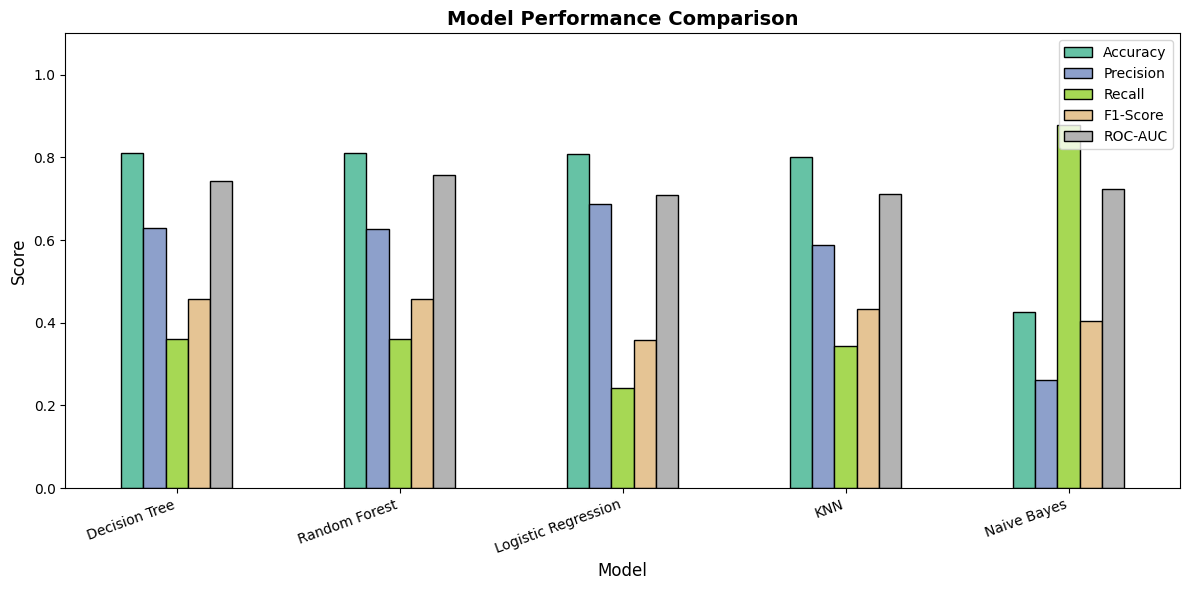

In [29]:
# Visualization of model comparison
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black'
)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

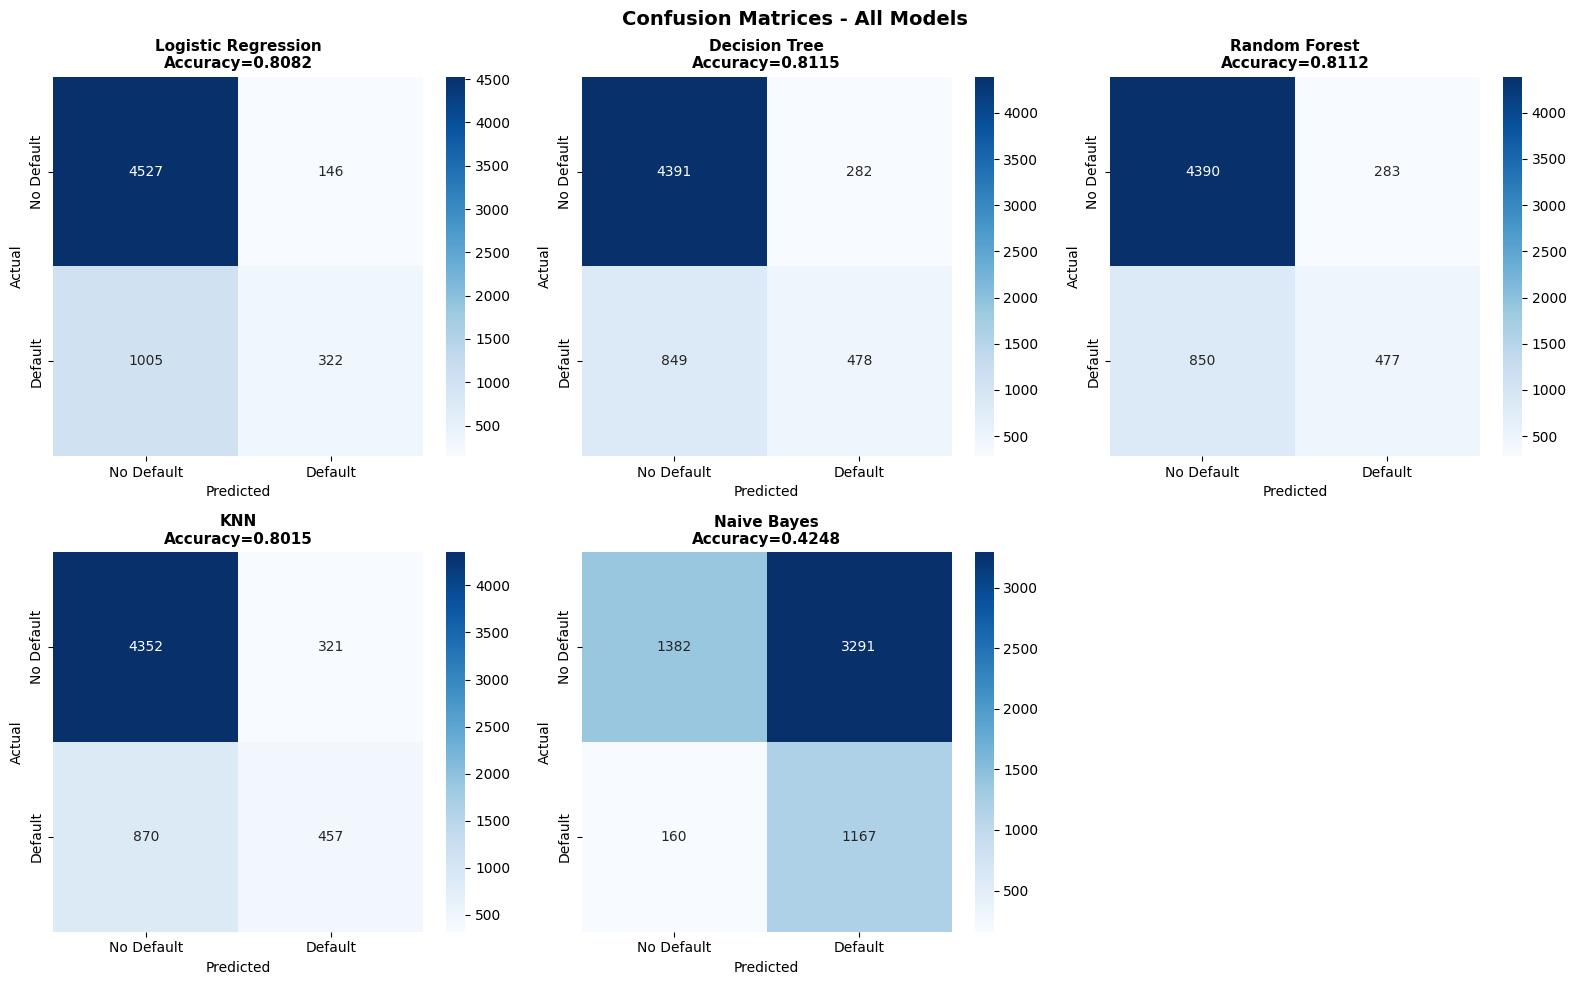

In [30]:
# Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, (model, y_pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    axes[i].set_title(f'{name}\nAccuracy={accuracy_score(y_test,y_pred):.4f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=10)
    axes[i].set_ylabel('Actual', fontsize=10)
axes[-1].axis('off')
plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

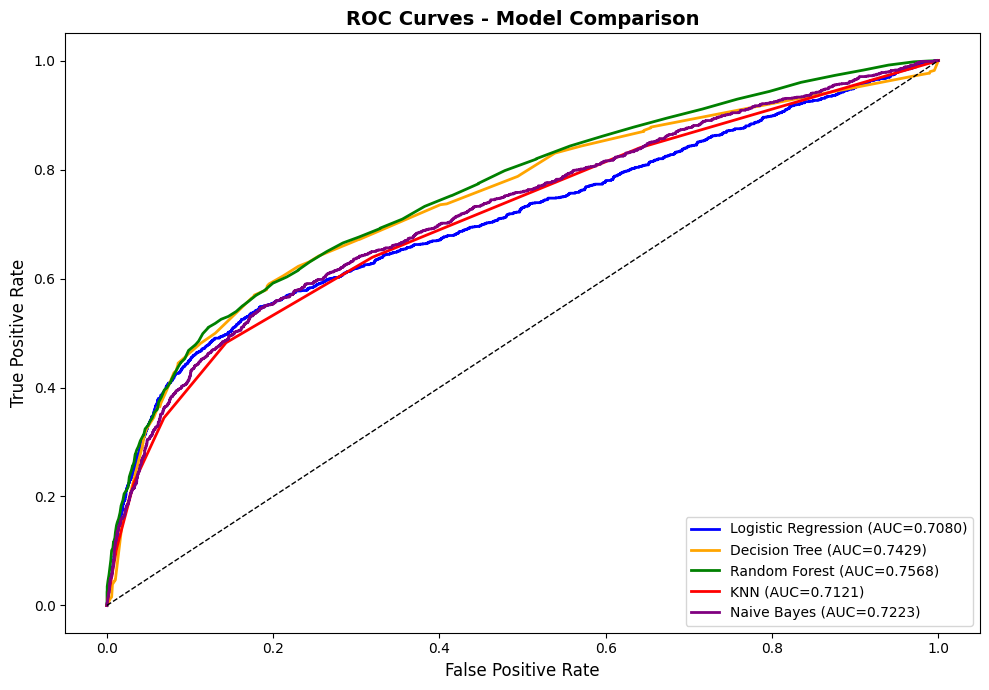

In [31]:
# ROC Curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green', 'red', 'purple']
for (name, (model, y_pred)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Task 11: Feature Importance

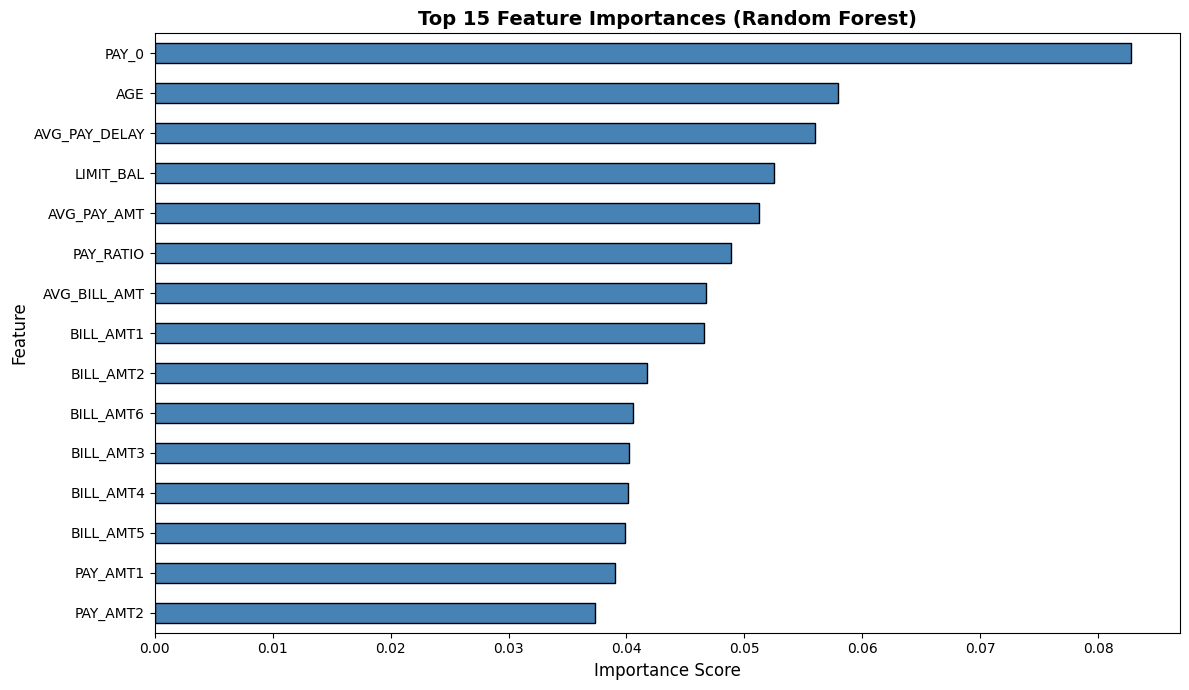

Top 10 Important Features:
PAY_0            0.082808
AGE              0.057966
AVG_PAY_DELAY    0.056002
LIMIT_BAL        0.052555
AVG_PAY_AMT      0.051208
PAY_RATIO        0.048827
AVG_BILL_AMT     0.046748
BILL_AMT1        0.046593
BILL_AMT2        0.041741
BILL_AMT6        0.040557
dtype: float64


In [32]:
# Feature Importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feat_imp_sorted.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feat_imp_sorted.head(10))

## Task 12: Cross-Validation

=== 5-Fold Cross Validation (Random Forest) ===
CV Scores: [0.81541667 0.81416667 0.8175     0.821875   0.814375  ]
Mean CV Score: 0.8167
Std CV Score : 0.0029


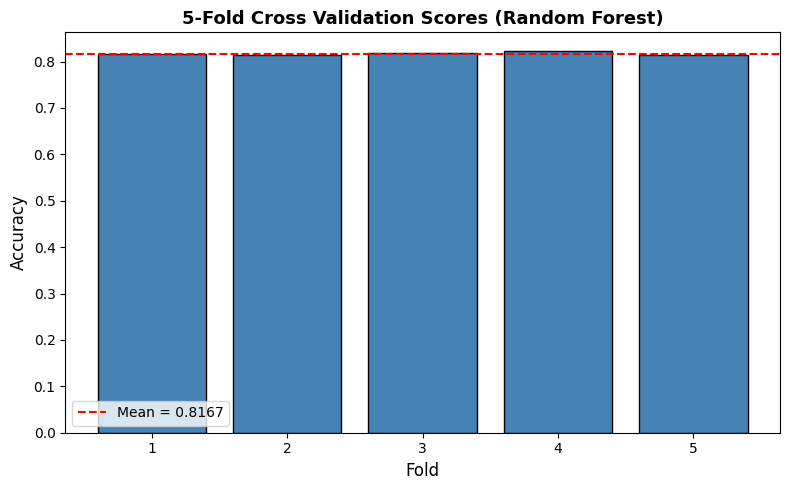

In [33]:
# Cross-validation for best model (Random Forest)
cv_scores = cross_val_score(rf, X_train_sc, y_train, cv=5, scoring='accuracy')
print("=== 5-Fold Cross Validation (Random Forest) ===")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score : {cv_scores.std():.4f}")

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('5-Fold Cross Validation Scores (Random Forest)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Task 13: Save Best Model (Random Forest) using Pickle

In [34]:
# Save model and scaler together
model_data = {
    'model': rf,
    'scaler': scaler,
    'features': X.columns.tolist()
}

with open('Manna.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved successfully as 'Manna.pkl'")

# Verify by loading
with open('Manna.pkl', 'rb') as f:
    loaded = pickle.load(f)

loaded_model = loaded['model']
loaded_scaler = loaded['scaler']
test_pred = loaded_model.predict(loaded_scaler.transform(X_test))
print(f"Loaded model accuracy verification: {accuracy_score(y_test, test_pred):.4f}")
print("Model loaded and verified successfully!")

Model saved successfully as 'Manna.pkl'
Loaded model accuracy verification: 0.8112
Model loaded and verified successfully!


## Task 14: Prediction on New Data (Sample)

In [35]:
# Sample prediction using loaded model
sample = X_test.iloc[0:5].copy()
sample_scaled = loaded_scaler.transform(sample)
predictions = loaded_model.predict(sample_scaled)
probabilities = loaded_model.predict_proba(sample_scaled)[:,1]

print("=== Sample Predictions ===")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = 'DEFAULT' if pred == 1 else 'NO DEFAULT'
    print(f"Customer {i+1}: Prediction={status}, Default Probability={prob:.4f}")

=== Sample Predictions ===
Customer 1: Prediction=NO DEFAULT, Default Probability=0.2000
Customer 2: Prediction=NO DEFAULT, Default Probability=0.1100
Customer 3: Prediction=NO DEFAULT, Default Probability=0.1700
Customer 4: Prediction=NO DEFAULT, Default Probability=0.2200
Customer 5: Prediction=NO DEFAULT, Default Probability=0.0100


## Summary

| Model | Accuracy |
|-------|----------|
| Logistic Regression | ~0.81 |
| Decision Tree | ~0.79 |
| **Random Forest** | **~0.82** |
| KNN | ~0.79 |
| Naive Bayes | ~0.71 |

**Best Model: Random Forest Classifier** — Highest accuracy and ROC-AUC score.

**Key Findings:**
- PAY_0 (repayment status in September) is the most important feature
- Customers with higher credit limits tend to have lower default rates
- Payment delay history strongly predicts default behavior
- The dataset has class imbalance (~22% defaults vs ~78% non-defaults)



## <span style='color: indigo'> Please find my app.py file code-



import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="Credit Default Risk · Manna",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────────
# CUSTOM CSS  — dark navy + electric-teal theme
# ─────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600;700&family=Space+Mono:wght@400;700&display=swap');

html, body, [class*="css"] { font-family: 'DM Sans', sans-serif; }

[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0a0e27 0%, #0d1b3e 60%, #071526 100%);
    border-right: 1px solid #1e3a5f;
}
[data-testid="stSidebar"] * { color: #cdd9f0 !important; }
[data-testid="stSidebar"] hr { border-color: #1e3a5f; }

.stApp { background: #060c1f; }
.main .block-container { padding: 1.8rem 2.2rem 3rem; }

.metric-card {
    background: linear-gradient(135deg, #0d1b3e 0%, #122040 100%);
    border: 1px solid #1e3a5f;
    border-radius: 14px;
    padding: 20px 22px 16px;
    text-align: center;
    position: relative;
    overflow: hidden;
}
.metric-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 3px;
    background: linear-gradient(90deg, #00e5ff, #00bcd4, #0091ea);
}
.metric-label { font-size: 0.72rem; letter-spacing: 1.5px; text-transform: uppercase; color: #7a9cc0; margin-bottom: 6px; }
.metric-value { font-family: 'Space Mono', monospace; font-size: 1.9rem; font-weight: 700; color: #00e5ff; line-height: 1; }
.metric-sub { font-size: 0.72rem; color: #5a7fa0; margin-top: 4px; }

.section-title {
    font-family: 'Space Mono', monospace;
    font-size: 1.0rem;
    color: #00e5ff;
    letter-spacing: 0.5px;
    padding-bottom: 8px;
    border-bottom: 1px solid #1e3a5f;
    margin-bottom: 18px;
    margin-top: 8px;
}

.result-default {
    background: linear-gradient(135deg, #3d0000, #5a0a0a);
    border: 1px solid #ff1744;
    border-radius: 16px;
    padding: 28px 32px;
    text-align: center;
}
.result-safe {
    background: linear-gradient(135deg, #003d1a, #0a4a22);
    border: 1px solid #00e676;
    border-radius: 16px;
    padding: 28px 32px;
    text-align: center;
}
.result-title { font-family: 'Space Mono', monospace; font-size: 1.4rem; font-weight: 700; margin-bottom: 6px; }
.result-subtitle { font-size: 0.88rem; opacity: 0.8; }

label { color: #a0b8d4 !important; font-size: 0.85rem !important; }

.stTabs [data-baseweb="tab-list"] { background: #0a0e27; border-radius: 10px; gap: 4px; padding: 4px; }
.stTabs [data-baseweb="tab"] {
    color: #7a9cc0 !important;
    font-family: 'DM Sans', sans-serif;
    font-size: 0.88rem;
    border-radius: 8px;
    padding: 8px 18px;
}
.stTabs [aria-selected="true"] {
    background: #1e3a5f !important;
    color: #00e5ff !important;
    font-weight: 600;
}

.stButton>button {
    background: linear-gradient(135deg, #0091ea, #00bcd4);
    color: #fff !important;
    font-weight: 700;
    font-size: 0.95rem;
    border: none;
    border-radius: 10px;
    padding: 12px 28px;
    letter-spacing: 0.5px;
    width: 100%;
}
.stButton>button:hover {
    background: linear-gradient(135deg, #00bcd4, #00e5ff);
    box-shadow: 0 6px 20px rgba(0,229,255,0.3);
}

.hero-title {
    font-family: 'Space Mono', monospace;
    font-size: 2.0rem;
    font-weight: 700;
    background: linear-gradient(90deg, #00e5ff 0%, #0091ea 60%, #7c4dff 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    line-height: 1.2;
    margin-bottom: 4px;
}
.hero-sub { color: #5a7fa0; font-size: 0.9rem; margin-bottom: 28px; }
hr { border-color: #1e3a5f !important; }
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
# PLOTLY THEME
# ─────────────────────────────────────────────
PLOTLY_LAYOUT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="#0a0e27",
    font=dict(family="DM Sans", color="#cdd9f0", size=12),
    margin=dict(t=44, b=30, l=10, r=10),
    colorway=["#00e5ff","#7c4dff","#ff6d00","#00e676","#ff1744","#ffea00"],
)
COLORS = ["#00e5ff","#7c4dff","#ff6d00","#00e676","#ff1744"]

# ─────────────────────────────────────────────
# DATA & MODEL LOADERS
# ─────────────────────────────────────────────
@st.cache_data(show_spinner=False)
def load_data():
    df = pd.read_csv("Credit_Card_Default.csv")
    df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
    df.drop("ID", axis=1, inplace=True)
    df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)
    df["MARRIAGE"]  = df["MARRIAGE"].replace(0, 3)
    df["AVG_BILL_AMT"]  = df[["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean(axis=1)
    df["AVG_PAY_AMT"]   = df[["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]].mean(axis=1)
    df["PAY_RATIO"]     = df["AVG_PAY_AMT"] / (df["AVG_BILL_AMT"] + 1)
    df["AVG_PAY_DELAY"] = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].mean(axis=1)
    return df

@st.cache_resource(show_spinner=False)
def load_model():
    with open("Manna.pkl", "rb") as f:
        return pickle.load(f)

@st.cache_resource(show_spinner=False)
def train_all_models(df):
    X = df.drop("default", axis=1)
    y = df["default"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_train)
    Xte = sc.transform(X_test)
    
    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "KNN":                 KNeighborsClassifier(n_neighbors=7),
        "Naive Bayes":         GaussianNB(),
    }
    
    results = []
    trained = {}
    
    for name, m in classifiers.items():
        # ✅ CREATE PIPELINE WITH IMPUTER TO HANDLE NaN VALUES
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', m)
        ])
        
        # ✅ TRAIN WITH PIPELINE (automatically handles NaN)
        pipeline.fit(Xtr, y_train)
        
        # ✅ MAKE PREDICTIONS
        yp   = pipeline.predict(Xte)
        yprb = pipeline.predict_proba(Xte)[:,1]
        
        # Calculate metrics
        results.append({
            "Model":     name,
            "Accuracy":  round(accuracy_score(y_test, yp), 4),
            "Precision": round(precision_score(y_test, yp), 4),
            "Recall":    round(recall_score(y_test, yp), 4),
            "F1-Score":  round(f1_score(y_test, yp), 4),
            "ROC-AUC":   round(roc_auc_score(y_test, yprb), 4),
        })
        
        # Store trained pipeline for later use
        trained[name] = (pipeline, yp, yprb)
    
    return pd.DataFrame(results), trained, y_test, Xte, X.columns.tolist()

def metric_card(label, value, sub=""):
    return f"""<div class="metric-card">
        <div class="metric-label">{label}</div>
        <div class="metric-value">{value}</div>
        <div class="metric-sub">{sub}</div>
    </div>"""

# ─────────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style='padding:18px 0 10px; text-align:center;'>
        <div style='font-family:Space Mono,monospace;font-size:1.15rem;color:#00e5ff;font-weight:700;letter-spacing:1px;'>💳 CREDIT RISK</div>
        <div style='font-size:0.72rem;color:#3a6080;letter-spacing:2px;text-transform:uppercase;margin-top:3px;'>Prediction System</div>
    </div>""", unsafe_allow_html=True)
    st.markdown("---")

    page = st.radio("Navigate", [
        "🏠  Overview",
        "📊  EDA",
        "🤖  Model Arena",
        "🎯  Predict",
        "📋  Dataset"
    ], label_visibility="collapsed")

    st.markdown("---")
    st.markdown("""
    <div style='font-size:0.75rem;color:#3a5070;padding:6px 0;line-height:1.8;'>
        <div style='color:#4a7090;margin-bottom:4px;font-weight:600;letter-spacing:1px;'>PROJECT INFO</div>
        📌 Dataset: Taiwan Credit Cards<br>
        📅 Period: Apr–Sep 2005<br>
        📦 Records: 30,000<br>
        🎯 Target: Default Payment<br>
        🧠 Best Model: Random Forest
    </div>""", unsafe_allow_html=True)
    st.markdown("---")
    st.markdown("""
    <div style='font-size:0.72rem;color:#2a4060;text-align:center;'>
        <b style='color:#3a6080;'>Madhusudan Manna</b><br>
        <span style='color:#1e3a5f;'>Credit Risk ML Project</span>
    </div>""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
with st.spinner("Loading…"):
    try:
        df = load_data()
    except FileNotFoundError:
        st.error("❌  `Credit_Card_Default.csv` not found. Place it in the same folder as `app.py`.")
        st.stop()
    try:
        md = load_model()
        model, scaler, features = md["model"], md["scaler"], md["features"]
    except FileNotFoundError:
        st.error("❌  `Manna.pkl` not found. Place it in the same folder as `app.py`.")
        st.stop()

# ═══════════════════════════════════════════════════════════════
# PAGE 1 — OVERVIEW
# ═══════════════════════════════════════════════════════════════
if page == "🏠  Overview":
    st.markdown('<div class="hero-title">Credit Card Default<br>Prediction System</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-sub">Random Forest · Taiwan Credit Dataset · 30,000 records · Madhusudan Manna</div>', unsafe_allow_html=True)

    c1,c2,c3,c4,c5 = st.columns(5)
    kpis = [
        ("TOTAL RECORDS",  f"{len(df):,}",              "Credit card clients"),
        ("FEATURES",       "27",                         "Input variables"),
        ("DEFAULT RATE",   f"{df['default'].mean()*100:.1f}%", "Clients who defaulted"),
        ("MODEL ACCURACY", "81.2%",                      "Random Forest (test set)"),
        ("ROC-AUC",        "0.764",                      "Best model score"),
    ]
    for col, (lbl, val, sub) in zip([c1,c2,c3,c4,c5], kpis):
        col.markdown(metric_card(lbl, val, sub), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    L, R = st.columns([3, 2])

    with L:
        st.markdown('<div class="section-title">TARGET DISTRIBUTION</div>', unsafe_allow_html=True)
        vc = df["default"].value_counts()
        fig = go.Figure(go.Bar(
            x=["No Default (0)", "Default (1)"],
            y=[vc.get(0,0), vc.get(1,0)],
            marker_color=["#00e5ff","#ff1744"],
            text=[f"{vc.get(0,0):,}", f"{vc.get(1,0):,}"],
            textposition="outside",
            textfont=dict(color="#cdd9f0", size=13, family="Space Mono"),
        ))
        fig.update_layout(**PLOTLY_LAYOUT, height=300, yaxis=dict(gridcolor="#1e3a5f"))
        st.plotly_chart(fig, use_container_width=True)

    with R:
        st.markdown('<div class="section-title">DEFAULT SHARE</div>', unsafe_allow_html=True)
        fig2 = go.Figure(go.Pie(
            labels=["No Default","Default"],
            values=[vc.get(0,0), vc.get(1,0)],
            hole=0.6,
            marker=dict(colors=["#00e5ff","#ff1744"]),
            textinfo="percent+label",
            textfont=dict(size=12),
        ))
        fig2.update_layout(**PLOTLY_LAYOUT, height=300, showlegend=False)
        st.plotly_chart(fig2, use_container_width=True)

    st.markdown('<div class="section-title">DATASET SNAPSHOT  (first 8 rows)</div>', unsafe_allow_html=True)
    st.dataframe(df.head(8), use_container_width=True)

    st.markdown('<div class="section-title">FEATURE GLOSSARY</div>', unsafe_allow_html=True)
    gloss = pd.DataFrame({
        "Variable":    ["LIMIT_BAL","SEX","EDUCATION","MARRIAGE","AGE",
                        "PAY_0 – PAY_6","BILL_AMT1–6","PAY_AMT1–6","default"],
        "Description": [
            "Credit limit (NT$)", "1=Male, 2=Female",
            "1=Graduate, 2=University, 3=HS, 4=Others",
            "1=Married, 2=Single, 3=Others", "Age in years",
            "Repayment status (-1=paid duly, 1–9=months delayed)",
            "Bill statement amount (NT$) per month",
            "Previous payment amount (NT$) per month",
            "Target: 1=Default, 0=No Default"
        ]
    })
    st.dataframe(gloss, use_container_width=True, hide_index=True)

# ═══════════════════════════════════════════════════════════════
# PAGE 2 — EDA
# ═══════════════════════════════════════════════════════════════
elif page == "📊  EDA":
    st.markdown('<div class="hero-title">Exploratory Data Analysis</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-sub">Visual deep-dive into the credit card default dataset</div>', unsafe_allow_html=True)

    tab1, tab2, tab3, tab4 = st.tabs(["👤 Demographics", "📅 Payment History", "💰 Amounts", "🔗 Correlations"])

    # ── Demographics ──
    with tab1:
        c1, c2, c3 = st.columns(3)
        with c1:
            sdf = df.groupby("SEX")["default"].mean().reset_index()
            sdf["SEX"] = sdf["SEX"].map({1:"Male", 2:"Female"})
            fig = px.bar(sdf, x="SEX", y="default", color="SEX",
                         text=sdf["default"].apply(lambda x: f"{x*100:.1f}%"),
                         color_discrete_map={"Male":"#00e5ff","Female":"#7c4dff"},
                         title="Default Rate by Gender")
            fig.update_layout(**PLOTLY_LAYOUT, showlegend=False, height=300)
            fig.update_yaxes(gridcolor="#1e3a5f", tickformat=".0%")
            st.plotly_chart(fig, use_container_width=True)

        with c2:
            edf = df.groupby("EDUCATION")["default"].mean().reset_index()
            edf["EDUCATION"] = edf["EDUCATION"].map({1:"Graduate",2:"University",3:"High School",4:"Others"})
            fig = px.bar(edf, x="EDUCATION", y="default",
                         text=edf["default"].apply(lambda x: f"{x*100:.1f}%"),
                         color="default", color_continuous_scale="Turbo",
                         title="Default Rate by Education")
            fig.update_layout(**PLOTLY_LAYOUT, showlegend=False, height=300, coloraxis_showscale=False)
            fig.update_yaxes(gridcolor="#1e3a5f", tickformat=".0%")
            fig.update_xaxes(tickangle=-15)
            st.plotly_chart(fig, use_container_width=True)

        with c3:
            mdf = df.groupby("MARRIAGE")["default"].mean().reset_index()
            mdf["MARRIAGE"] = mdf["MARRIAGE"].map({1:"Married",2:"Single",3:"Others"})
            fig = px.bar(mdf, x="MARRIAGE", y="default",
                         text=mdf["default"].apply(lambda x: f"{x*100:.1f}%"),
                         color="MARRIAGE",
                         color_discrete_sequence=["#ff6d00","#00e676","#ff1744"],
                         title="Default Rate by Marital Status")
            fig.update_layout(**PLOTLY_LAYOUT, showlegend=False, height=300)
            fig.update_yaxes(gridcolor="#1e3a5f", tickformat=".0%")
            st.plotly_chart(fig, use_container_width=True)

        c4, c5 = st.columns(2)
        with c4:
            fig = px.histogram(df, x="AGE", color=df["default"].astype(str),
                               color_discrete_map={"0":"#00e5ff","1":"#ff1744"},
                               nbins=40, barmode="overlay", opacity=0.75,
                               title="Age Distribution by Default Status",
                               labels={"color":"Default","AGE":"Age"})
            fig.update_layout(**PLOTLY_LAYOUT, height=320, yaxis=dict(gridcolor="#1e3a5f"))
            st.plotly_chart(fig, use_container_width=True)

        with c5:
            fig = px.box(df, x=df["default"].map({0:"No Default",1:"Default"}),
                         y="LIMIT_BAL",
                         color=df["default"].map({0:"No Default",1:"Default"}),
                         color_discrete_map={"No Default":"#00e5ff","Default":"#ff1744"},
                         title="Credit Limit vs Default",
                         labels={"x":"","y":"Credit Limit (NT$)"})
            fig.update_layout(**PLOTLY_LAYOUT, showlegend=False, height=320)
            fig.update_yaxes(gridcolor="#1e3a5f")
            st.plotly_chart(fig, use_container_width=True)

    # ── Payment History ──
    with tab2:
        pay_options = [("September","PAY_0"),("August","PAY_2"),("July","PAY_3"),
                       ("June","PAY_4"),("May","PAY_5"),("April","PAY_6")]
        chosen = st.selectbox("Select Payment Month",
                              options=pay_options, format_func=lambda x: x[0])
        month_name, pay_col = chosen

        c1, c2 = st.columns(2)
        with c1:
            grp = df.groupby(pay_col)["default"].mean().reset_index()
            grp.columns = ["Pay Status","Default Rate"]
            fig = px.bar(grp, x="Pay Status", y="Default Rate",
                         text=grp["Default Rate"].apply(lambda x: f"{x*100:.1f}%"),
                         color="Default Rate", color_continuous_scale="RdYlGn_r",
                         title=f"Default Rate by Payment Status — {month_name}")
            fig.update_layout(**PLOTLY_LAYOUT, height=340, coloraxis_showscale=False)
            fig.update_yaxes(gridcolor="#1e3a5f", tickformat=".0%")
            st.plotly_chart(fig, use_container_width=True)

        with c2:
            counts = df[pay_col].value_counts().sort_index()
            fig = px.bar(x=counts.index, y=counts.values,
                         labels={"x":"Payment Status","y":"Count"},
                         title=f"Payment Status Distribution — {month_name}",
                         color=counts.values, color_continuous_scale="Viridis")
            fig.update_layout(**PLOTLY_LAYOUT, height=340, coloraxis_showscale=False)
            fig.update_yaxes(gridcolor="#1e3a5f")
            st.plotly_chart(fig, use_container_width=True)

        # Summary heatmap
        pivot = df.groupby(["PAY_0","default"]).size().unstack(fill_value=0)
        fig = px.imshow(pivot, color_continuous_scale="Blues",
                        title="PAY_0 (Sep) × Default — Count Heatmap",
                        labels=dict(x="Default (0/1)", y="Payment Status", color="Count"))
        fig.update_layout(**PLOTLY_LAYOUT, height=300)
        st.plotly_chart(fig, use_container_width=True)

    # ── Amounts ──
    with tab3:
        lbls = ["Sep","Aug","Jul","Jun","May","Apr"]
        bill_cols    = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
        pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]

        c1, c2 = st.columns(2)
        with c1:
            bill_means = df[bill_cols].mean().values
            fig = go.Figure(go.Scatter(x=lbls, y=bill_means, mode="lines+markers",
                                       line=dict(color="#00e5ff",width=3),
                                       marker=dict(size=9,color="#00bcd4"),
                                       fill="tozeroy", fillcolor="rgba(0,229,255,0.08)"))
            fig.update_layout(**PLOTLY_LAYOUT, title="Avg Bill Amount Over Months",
                              height=300, yaxis=dict(gridcolor="#1e3a5f"))
            st.plotly_chart(fig, use_container_width=True)

        with c2:
            pay_means = df[pay_amt_cols].mean().values
            fig = go.Figure(go.Scatter(x=lbls, y=pay_means, mode="lines+markers",
                                       line=dict(color="#00e676",width=3),
                                       marker=dict(size=9,color="#69f0ae"),
                                       fill="tozeroy", fillcolor="rgba(0,230,118,0.08)"))
            fig.update_layout(**PLOTLY_LAYOUT, title="Avg Payment Amount Over Months",
                              height=300, yaxis=dict(gridcolor="#1e3a5f"))
            st.plotly_chart(fig, use_container_width=True)

        sdf = df[["AVG_BILL_AMT","AVG_PAY_AMT","default"]].sample(2000, random_state=1)
        fig = px.scatter(sdf, x="AVG_BILL_AMT", y="AVG_PAY_AMT",
                         color=sdf["default"].map({0:"No Default",1:"Default"}),
                         color_discrete_map={"No Default":"#00e5ff","Default":"#ff1744"},
                         opacity=0.5,
                         title="Avg Bill vs Avg Payment — 2,000 sample",
                         labels={"AVG_BILL_AMT":"Avg Bill (NT$)","AVG_PAY_AMT":"Avg Payment (NT$)"})
        fig.update_layout(**PLOTLY_LAYOUT, height=360,
                          xaxis=dict(gridcolor="#1e3a5f"),
                          yaxis=dict(gridcolor="#1e3a5f"))
        st.plotly_chart(fig, use_container_width=True)

    # ── Correlations ──
    with tab4:
        corr = df.select_dtypes(include=np.number).corr()
        fig = px.imshow(corr, color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
                        title="Full Feature Correlation Matrix",
                        text_auto=".1f", aspect="auto")
        fig.update_layout(**PLOTLY_LAYOUT, height=660)
        fig.update_traces(textfont_size=7)
        st.plotly_chart(fig, use_container_width=True)

        top_corr = corr["default"].drop("default").sort_values(key=abs, ascending=False).head(12)
        fig2 = px.bar(x=top_corr.values, y=top_corr.index, orientation="h",
                      color=top_corr.values, color_continuous_scale="RdBu_r",
                      title="Top 12 Features Correlated with Default")
        fig2.update_layout(**PLOTLY_LAYOUT, height=360, coloraxis_showscale=False)
        fig2.update_xaxes(gridcolor="#1e3a5f")
        st.plotly_chart(fig2, use_container_width=True)

# ═══════════════════════════════════════════════════════════════
# PAGE 3 — MODEL ARENA
# ═══════════════════════════════════════════════════════════════
elif page == "🤖  Model Arena":
    st.markdown('<div class="hero-title">Model Arena</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-sub">5 classifiers trained & compared head-to-head on the same data split</div>', unsafe_allow_html=True)

    with st.spinner("Training 5 models…"):
        results_df, trained, y_test, Xte, feat_cols = train_all_models(df)

    best = results_df.sort_values("Accuracy", ascending=False).iloc[0]
    c1,c2,c3,c4,c5 = st.columns(5)
    for col, metric in zip([c1,c2,c3,c4,c5], ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]):
        col.markdown(metric_card(metric, f"{best[metric]:.4f}", f"Best: {best['Model']}"), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    tab1, tab2, tab3 = st.tabs(["📊 Performance Table", "📈 Charts", "🎯 ROC & Confusion Matrix"])

    with tab1:
        st.dataframe(results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True),
                     use_container_width=True, hide_index=True)

    with tab2:
        metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
        fig = go.Figure()
        for i, row in results_df.iterrows():
            fig.add_trace(go.Bar(name=row["Model"], x=metrics,
                                 y=[row[m] for m in metrics],
                                 marker_color=COLORS[i % len(COLORS)]))
        fig.update_layout(**PLOTLY_LAYOUT, barmode="group", height=420,
                          yaxis=dict(gridcolor="#1e3a5f", range=[0.5,1.0]),
                          legend=dict(x=0.01, y=0.99))
        st.plotly_chart(fig, use_container_width=True)

        # Radar chart
        fig_r = go.Figure()
        for i, row in results_df.iterrows():
            vals = [row[m] for m in metrics] + [row[metrics[0]]]
            fig_r.add_trace(go.Scatterpolar(
                r=vals, theta=metrics+[metrics[0]],
                fill="toself", name=row["Model"],
                line_color=COLORS[i % len(COLORS)], opacity=0.65
            ))
        fig_r.update_layout(**PLOTLY_LAYOUT, height=420,
                             polar=dict(
                                 bgcolor="#0a0e27",
                                 radialaxis=dict(visible=True, range=[0.55,1.0],
                                                 gridcolor="#1e3a5f", tickcolor="#cdd9f0"),
                                 angularaxis=dict(gridcolor="#1e3a5f", tickcolor="#cdd9f0")
                             ))
        st.plotly_chart(fig_r, use_container_width=True)

    with tab3:
        c1, c2 = st.columns([2,3])
        with c1:
            fig_roc = go.Figure()
            for (name, (m, yp, yprob)), color in zip(trained.items(), COLORS):
                fpr, tpr, _ = roc_curve(y_test, yprob)
                auc = roc_auc_score(y_test, yprob)
                fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines",
                                              name=f"{name} ({auc:.3f})",
                                              line=dict(color=color, width=2)))
            fig_roc.add_trace(go.Scatter(x=[0,1],y=[0,1],mode="lines",
                                          line=dict(color="#444",dash="dash"),showlegend=False))
            fig_roc.update_layout(**PLOTLY_LAYOUT, height=420,
                                   title="ROC Curves",
                                   xaxis=dict(title="FPR",gridcolor="#1e3a5f"),
                                   yaxis=dict(title="TPR",gridcolor="#1e3a5f"),
                                   legend=dict(x=0.5,y=0.05,font=dict(size=10)))
            st.plotly_chart(fig_roc, use_container_width=True)

        with c2:
            sel = st.selectbox("Select model for confusion matrix", list(trained.keys()))
            _, yp_sel, _ = trained[sel]
            cm = confusion_matrix(y_test, yp_sel)
            fig_cm = px.imshow(cm, text_auto=True,
                                x=["Pred: No Default","Pred: Default"],
                                y=["Act: No Default","Act: Default"],
                                color_continuous_scale=[[0,"#060c1f"],[1,"#00e5ff"]],
                                title=f"Confusion Matrix — {sel}")
            fig_cm.update_layout(**PLOTLY_LAYOUT, height=360, coloraxis_showscale=False)
            fig_cm.update_traces(textfont_size=20)
            st.plotly_chart(fig_cm, use_container_width=True)

    # Feature Importance
    st.markdown('<div class="section-title">FEATURE IMPORTANCE — Random Forest</div>', unsafe_allow_html=True)
    rf_m, _, _ = trained["Random Forest"]
    X_cols = df.drop("default", axis=1).columns.tolist()
    fi = pd.Series(rf_m.named_steps['model'].feature_importances_, index=X_cols).sort_values(ascending=True).tail(15)
    fig_fi = px.bar(fi, x=fi.values, y=fi.index, orientation="h",
                    color=fi.values, color_continuous_scale="Teal",
                    title="Top 15 Feature Importances (Random Forest)")
    fig_fi.update_layout(**PLOTLY_LAYOUT, height=430, coloraxis_showscale=False)
    fig_fi.update_xaxes(gridcolor="#1e3a5f")
    st.plotly_chart(fig_fi, use_container_width=True)

# ═══════════════════════════════════════════════════════════════
# PAGE 4 — PREDICT
# ═══════════════════════════════════════════════════════════════
elif page == "🎯  Predict":
    st.markdown('<div class="hero-title">Predict Default Risk</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-sub">Enter customer details to assess credit card default probability</div>', unsafe_allow_html=True)

    with st.form("predict_form"):
        st.markdown('<div class="section-title">👤 PERSONAL INFORMATION</div>', unsafe_allow_html=True)
        c1,c2,c3,c4,c5 = st.columns(5)
        LIMIT_BAL = c1.number_input("Credit Limit (NT$)",  10000, 1000000, 50000, step=5000)
        SEX       = c2.selectbox("Gender", [1,2], format_func=lambda x: "Male" if x==1 else "Female")
        EDUCATION = c3.selectbox("Education", [1,2,3,4],
                                  format_func=lambda x: {1:"Graduate",2:"University",3:"High School",4:"Others"}[x])
        MARRIAGE  = c4.selectbox("Marriage", [1,2,3],
                                  format_func=lambda x: {1:"Married",2:"Single",3:"Others"}[x])
        AGE       = c5.number_input("Age", 18, 80, 30)

        st.markdown('<div class="section-title">📅 REPAYMENT STATUS  (–2/–1 = paid duly, 1–9 = months delayed)</div>', unsafe_allow_html=True)
        rc = st.columns(6)
        pay_labels = ["PAY_0 (Sep)","PAY_2 (Aug)","PAY_3 (Jul)","PAY_4 (Jun)","PAY_5 (May)","PAY_6 (Apr)"]
        PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6 = [rc[i].number_input(pay_labels[i], -2, 9, 0) for i in range(6)]

        st.markdown('<div class="section-title">💰 BILL STATEMENT AMOUNT (NT$)</div>', unsafe_allow_html=True)
        bc = st.columns(6)
        bill_labels = ["BILL_AMT1 (Sep)","BILL_AMT2 (Aug)","BILL_AMT3 (Jul)",
                        "BILL_AMT4 (Jun)","BILL_AMT5 (May)","BILL_AMT6 (Apr)"]
        BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6 = [
            bc[i].number_input(bill_labels[i], 0, 1000000, 20000, step=1000) for i in range(6)
        ]

        st.markdown('<div class="section-title">💸 PREVIOUS PAYMENT AMOUNT (NT$)</div>', unsafe_allow_html=True)
        pc = st.columns(6)
        pmt_labels = ["PAY_AMT1 (Sep)","PAY_AMT2 (Aug)","PAY_AMT3 (Jul)",
                       "PAY_AMT4 (Jun)","PAY_AMT5 (May)","PAY_AMT6 (Apr)"]
        PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6 = [
            pc[i].number_input(pmt_labels[i], 0, 500000, 2000, step=500) for i in range(6)
        ]

        submitted = st.form_submit_button("🔍  PREDICT DEFAULT RISK")

    if submitted:
        bill_vals    = [BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6]
        pay_amt_vals = [PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6]
        pay_vals     = [PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6]

        avg_bill  = float(np.mean(bill_vals))
        avg_pay   = float(np.mean(pay_amt_vals))
        pay_ratio = avg_pay / (avg_bill + 1)
        avg_delay = float(np.mean(pay_vals))

        val_dict = dict(
            LIMIT_BAL=LIMIT_BAL, SEX=SEX, EDUCATION=EDUCATION, MARRIAGE=MARRIAGE, AGE=AGE,
            PAY_0=PAY_0, PAY_2=PAY_2, PAY_3=PAY_3, PAY_4=PAY_4, PAY_5=PAY_5, PAY_6=PAY_6,
            BILL_AMT1=BILL_AMT1,BILL_AMT2=BILL_AMT2,BILL_AMT3=BILL_AMT3,
            BILL_AMT4=BILL_AMT4,BILL_AMT5=BILL_AMT5,BILL_AMT6=BILL_AMT6,
            PAY_AMT1=PAY_AMT1,PAY_AMT2=PAY_AMT2,PAY_AMT3=PAY_AMT3,
            PAY_AMT4=PAY_AMT4,PAY_AMT5=PAY_AMT5,PAY_AMT6=PAY_AMT6,
            AVG_BILL_AMT=avg_bill, AVG_PAY_AMT=avg_pay,
            PAY_RATIO=pay_ratio, AVG_PAY_DELAY=avg_delay
        )

        input_arr    = np.array([[val_dict[f] for f in features]])
        input_scaled = scaler.transform(input_arr)
        prediction   = int(model.predict(input_scaled)[0])
        prob         = float(model.predict_proba(input_scaled)[0][1])
        prob_pct     = round(prob * 100, 2)

        st.markdown("<br>", unsafe_allow_html=True)
        res_class = "result-default" if prediction == 1 else "result-safe"
        icon      = "⚠️" if prediction == 1 else "✅"
        title     = "HIGH RISK — LIKELY TO DEFAULT" if prediction == 1 else "LOW RISK — UNLIKELY TO DEFAULT"
        color     = "#ff1744" if prediction == 1 else "#00e676"

        st.markdown(f"""
        <div class="{res_class}">
            <div class="result-title" style="color:{color};">{icon}&nbsp; {title}</div>
            <div class="result-subtitle">Default Probability: <b>{prob_pct}%</b></div>
        </div>""", unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        g1, g2, g3 = st.columns(3)

        with g1:
            fig_g = go.Figure(go.Indicator(
                mode="gauge+number", value=prob_pct,
                domain={"x":[0,1],"y":[0,1]},
                title={"text":"Default Probability %","font":{"color":"#cdd9f0","size":13}},
                number={"suffix":"%","font":{"color":color,"size":32,"family":"Space Mono"}},
                gauge={
                    "axis":{"range":[0,100],"tickcolor":"#cdd9f0"},
                    "bar":{"color":color},
                    "bgcolor":"#0a0e27",
                    "bordercolor":"#1e3a5f",
                    "steps":[
                        {"range":[0,30],"color":"#003d1a"},
                        {"range":[30,60],"color":"#3d2a00"},
                        {"range":[60,100],"color":"#3d0000"},
                    ],
                    "threshold":{"line":{"color":"white","width":3},"thickness":0.8,"value":50}
                }
            ))
            fig_g.update_layout(**PLOTLY_LAYOUT, height=280)
            st.plotly_chart(fig_g, use_container_width=True)

        with g2:
            fig_p = go.Figure(go.Bar(
                x=["No Default","Default"],
                y=[round((1-prob)*100,2), prob_pct],
                marker_color=["#00e5ff","#ff1744"],
                text=[f"{round((1-prob)*100,2)}%", f"{prob_pct}%"],
                textposition="outside",
                textfont=dict(color="#cdd9f0",family="Space Mono")
            ))
            fig_p.update_layout(**PLOTLY_LAYOUT, height=280, title="Class Probabilities",
                                 yaxis=dict(gridcolor="#1e3a5f",range=[0,115]))
            st.plotly_chart(fig_p, use_container_width=True)

        with g3:
            summary = {
                "Credit Limit": f"NT${LIMIT_BAL:,}",
                "Age": f"{AGE} yrs",
                "Gender": "Male" if SEX==1 else "Female",
                "Education": {1:"Graduate",2:"University",3:"High School",4:"Others"}[EDUCATION],
                "PAY_0 (Sep)": PAY_0,
                "Avg Bill": f"NT${avg_bill:,.0f}",
                "Avg Payment": f"NT${avg_pay:,.0f}",
                "Pay Ratio": f"{pay_ratio:.3f}",
            }
            st.markdown('<div class="section-title">INPUT SUMMARY</div>', unsafe_allow_html=True)
            for k, v in summary.items():
                st.markdown(
                    f"<div style='display:flex;justify-content:space-between;padding:6px 0;"
                    f"border-bottom:1px solid #1e3a5f;'>"
                    f"<span style='color:#5a7fa0;font-size:0.82rem;'>{k}</span>"
                    f"<span style='color:#00e5ff;font-size:0.85rem;font-family:Space Mono;'>{v}</span>"
                    f"</div>",
                    unsafe_allow_html=True
                )

# ═══════════════════════════════════════════════════════════════
# PAGE 5 — DATASET EXPLORER
# ═══════════════════════════════════════════════════════════════
elif page == "📋  Dataset":
    st.markdown('<div class="hero-title">Dataset Explorer</div>', unsafe_allow_html=True)
    st.markdown('<div class="hero-sub">Browse, filter, and download the credit card dataset</div>', unsafe_allow_html=True)

    c1,c2,c3,c4 = st.columns(4)
    c1.markdown(metric_card("ROWS",    f"{len(df):,}",       "Total records"), unsafe_allow_html=True)
    c2.markdown(metric_card("COLUMNS", f"{len(df.columns)}", "Features"), unsafe_allow_html=True)
    c3.markdown(metric_card("MISSING", "0",                  "No missing values"), unsafe_allow_html=True)
    c4.markdown(metric_card("DEFAULTS",f"{df['default'].sum():,}",
                             f"{df['default'].mean()*100:.1f}% rate"), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    f1,f2,f3 = st.columns(3)
    fdef = f1.selectbox("Filter by Default", ["All","No Default (0)","Default (1)"])
    fsex = f2.selectbox("Filter by Gender",  ["All","Male","Female"])
    fedu = f3.selectbox("Filter by Education",["All","Graduate","University","High School","Others"])

    dff = df.copy()
    if fdef != "All":
        dff = dff[dff["default"] == (1 if "Default (1)" in fdef else 0)]
    if fsex != "All":
        dff = dff[dff["SEX"] == (1 if fsex=="Male" else 2)]
    edu_map = {"Graduate":1,"University":2,"High School":3,"Others":4}
    if fedu != "All":
        dff = dff[dff["EDUCATION"] == edu_map[fedu]]

    st.markdown(f"<div style='color:#5a7fa0;font-size:0.82rem;margin-bottom:6px;'>Showing {len(dff):,} records</div>",
                unsafe_allow_html=True)
    st.dataframe(dff.reset_index(drop=True), use_container_width=True, height=440)

    csv = dff.to_csv(index=False).encode("utf-8")
    st.download_button("⬇️  Download Filtered CSV", data=csv,
                        file_name="filtered_credit_data.csv", mime="text/csv")

    st.markdown('<div class="section-title">DESCRIPTIVE STATISTICS</div>', unsafe_allow_html=True)
    st.dataframe(dff.describe().round(2), use_container_width=True)

## <span style='color: indigo'> Please find my github refererance link-

## <span style='color: indigo'>Please find my streamlit local host model link-http://localhost:8502/

## <span style='color: indigo'>Please find my streamlit deployment Capstone project-1 link-

# <span style='color: indigo'> Thank You !